# Ridge Regression

**Objective**: Train a regularised linear model to predict `Log_Unit_Price`, then back-transform predictions via `exp()` for evaluation against raw unit price.

**Steps:**
1. Load preprocessed train/test splits from `data/processed/`
2. Define numerical vs binary columns — scale numerical only
3. Baseline Ridge (alpha=1.0) with 5-fold CV
4. Hyperparameter tuning — GridSearchCV over alpha
5. Evaluate best model on test set
6. Coefficient interpretation
7. Save model

**Target**: `Log_Unit_Price` (linear models require log-transformed target for normality + homoscedasticity)

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

os.makedirs("../models", exist_ok=True)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv")

y_train_log = y_train["Log_Unit_Price"]
y_test_log  = y_test["Log_Unit_Price"]
y_test_raw  = y_test["Unit Price ($ psf)"]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Columns: {list(X_train.columns)}")

X_train: (3025, 18)  X_test: (757, 18)
Columns: ['Log_Area', 'Remaining_Lease_Years', 'Lease_Remaining_Ratio', 'dist_to_mrt_m', 'GDP_YoY_Growth_Rate', 'CPI_All_Items', 'Unemployment_Rate', '10Y_Bond_Yield', 'SORA_3M_Compounded', 'Cement_Bulk_Per_Tonne', 'Planning_Area_Encoded', 'Region_East Region', 'Region_North Region', 'Region_North-East Region', 'Region_West Region', 'Floor Level_Non-First Floor', 'Floor Level_Unknown', 'Type of Sale_Resale']


## 2. Feature Setup — Numerical vs Binary Columns

**StandardScaler applies to numerical features only.**

Binary/one-hot encoded columns are already on [0, 1] scale — applying StandardScaler would distort their meaning (e.g. a 0.5 value would be meaningless for a binary flag).

`Planning_Area_Encoded` is treated as numerical — it holds continuous mean price values, not category integers.

In [2]:
NUMERICAL_COLS = [
    "Log_Area",
    "Remaining_Lease_Years",
    "Lease_Remaining_Ratio",
    "dist_to_mrt_m",
    "GDP_YoY_Growth_Rate",
    "CPI_All_Items",
    "Unemployment_Rate",
    "10Y_Bond_Yield",
    "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne",
    "Planning_Area_Encoded",
]

BINARY_COLS = [
    "Region_East Region",
    "Region_North Region",
    "Region_North-East Region",
    "Region_West Region",
    "Floor Level_Non-First Floor",
    "Floor Level_Unknown",
    "Type of Sale_Resale",
]

print(f"Numerical (to scale): {len(NUMERICAL_COLS)}")
print(f"Binary (passthrough):  {len(BINARY_COLS)}")
print(f"Total features:        {len(NUMERICAL_COLS) + len(BINARY_COLS)}")

Numerical (to scale): 11
Binary (passthrough):  7
Total features:        18


## 3. Build Pipeline

**ColumnTransformer**:
- `StandardScaler` on numerical columns — z-score normalisation so Ridge L2 penalty is applied fairly across all features
- `passthrough` on binary columns — already on [0, 1] scale

**Pipeline**: preprocessor → Ridge. This ensures the scaler is fitted on training data only — no leakage into cross-validation folds.

In [3]:
preprocessor = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), NUMERICAL_COLS),
    ("passthrough", "passthrough", BINARY_COLS),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  ['Log_Area',
                                                   'Remaining_Lease_Years',
                                                   'Lease_Remaining_Ratio',
                                                   'dist_to_mrt_m',
                                                   'GDP_YoY_Growth_Rate',
                                                   'CPI_All_Items',
                                                   'Unemployment_Rate',
                                                   '10Y_Bond_Yield',
                                                   'SORA_3M_Compounded',
                                                   'Cement_Bulk_Per_Tonne',
                                                   'Planning_Area_Encoded']),
                                                 ('passthrough', 'passthrough',
                 

## 4. Baseline — 5-Fold Cross-Validation (alpha=1.0)

Evaluate on log-space RMSE first, then convert to original scale for interpretability.

**Why CV before test set**: The test set is held out until the very end. CV on train data gives an unbiased estimate of generalisation performance during model development.

In [4]:
cv_scores = cross_val_score(
    pipeline, X_train, y_train_log,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse = -cv_scores

print("Baseline Ridge (alpha=1.0) — 5-Fold CV Results (log-space RMSE):")
for i, rmse in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {rmse:.4f}")
print(f"\n  Mean RMSE:  {cv_rmse.mean():.4f}")
print(f"  Std RMSE:   {cv_rmse.std():.4f}")

# Approximate original-scale interpretation: exp(log_rmse) - 1 gives % error
print(f"\nApprox. % prediction error (exp(RMSE) - 1): {(np.exp(cv_rmse.mean()) - 1) * 100:.1f}%")

Baseline Ridge (alpha=1.0) — 5-Fold CV Results (log-space RMSE):
  Fold 1: 0.2157
  Fold 2: 0.2399
  Fold 3: 0.2166
  Fold 4: 0.2229
  Fold 5: 0.2102

  Mean RMSE:  0.2211
  Std RMSE:   0.0102

Approx. % prediction error (exp(RMSE) - 1): 24.7%


## 5. Hyperparameter Tuning — GridSearchCV over Alpha

**Alpha** controls regularisation strength:
- Low alpha (e.g. 0.01) → weak regularisation → closer to OLS → risk of overfitting
- High alpha (e.g. 1000) → strong regularisation → coefficients shrink toward zero → risk of underfitting

Search on a log scale — alpha effects are multiplicative, not additive.

In [5]:
param_grid = {"model__alpha": [0.01, 0.1, 1.0, 10, 50, 100, 500, 1000]}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train_log)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df["alpha"] = results_df["param_model__alpha"].astype(float)
results_df["cv_rmse"] = -results_df["mean_test_score"]
results_df["train_rmse"] = -results_df["mean_train_score"]

print("Alpha vs CV RMSE (log-space):")
print(results_df[["alpha", "train_rmse", "cv_rmse"]].to_string(index=False))
print(f"\nBest alpha: {grid_search.best_params_['model__alpha']}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

Alpha vs CV RMSE (log-space):
  alpha  train_rmse  cv_rmse
   0.01    0.219006 0.221082
   0.10    0.219006 0.221082
   1.00    0.219014 0.221082
  10.00    0.219535 0.221543
  50.00    0.223217 0.225063
 100.00    0.226677 0.228388
 500.00    0.241092 0.242294
1000.00    0.252396 0.253307

Best alpha: 0.1
Best CV RMSE: 0.2211


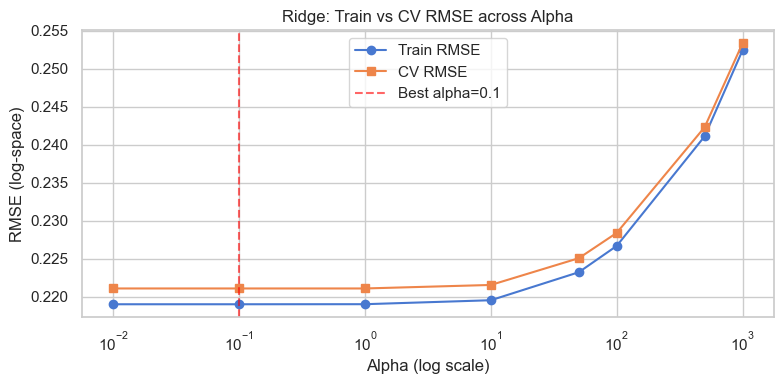

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(results_df["alpha"], results_df["train_rmse"], marker="o", label="Train RMSE")
ax.semilogx(results_df["alpha"], results_df["cv_rmse"], marker="s", label="CV RMSE")
ax.axvline(grid_search.best_params_["model__alpha"], color="red", linestyle="--", alpha=0.6, label=f"Best alpha={grid_search.best_params_['model__alpha']}")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("RMSE (log-space)")
ax.set_title("Ridge: Train vs CV RMSE across Alpha")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

**Touch the test set only once** — after hyperparameter selection is finalised.

Back-transform log predictions via `exp()` to get original `$ psf` scale for RMSE and R².

In [7]:
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_["model__alpha"]

# Log-space evaluation
y_pred_log = best_model.predict(X_test)
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2_log   = r2_score(y_test_log, y_pred_log)

# Original-scale evaluation (back-transform)
y_pred_raw = np.exp(y_pred_log)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_raw  = np.mean(np.abs(y_test_raw.values - y_pred_raw))
r2_raw   = r2_score(y_test_raw, y_pred_raw)

print(f"Best alpha: {best_alpha}")
print()
print(f"--- Log-space (target: Log_Unit_Price) ---")
print(f"  RMSE: {rmse_log:.4f}")
print(f"  R²:   {r2_log:.4f}")
print()
print(f"--- Original scale (target: Unit Price $ psf) ---")
print(f"  RMSE: ${rmse_raw:.2f} $/psf")
print(f"  MAE:  ${mae_raw:.2f} $/psf")
print(f"  R²:   {r2_raw:.4f}")
print()
print(f"Mean actual price:    ${y_test_raw.mean():.2f} $/psf")
print(f"RMSE as % of mean:    {rmse_raw / y_test_raw.mean() * 100:.1f}%")
print()
print(f"RMSE vs MAE: ${rmse_raw:.2f} vs ${mae_raw:.2f} $/psf  (gap = ${rmse_raw - mae_raw:.2f} $/psf)")
print(f"  -> {'RMSE >> MAE: model has some large outlier errors worth investigating' if (rmse_raw - mae_raw) > 20 else 'RMSE close to MAE: errors are fairly uniform, no severe outlier predictions'}")

Best alpha: 0.1

--- Log-space (target: Log_Unit_Price) ---
  RMSE: 0.2118
  R²:   0.7719

--- Original scale (target: Unit Price $ psf) ---
  RMSE: $82.60 $/psf
  MAE:  $61.04 $/psf
  R²:   0.7845

Mean actual price:    $439.87 $/psf
RMSE as % of mean:    18.8%

RMSE vs MAE: $82.60 vs $61.04 $/psf  (gap = $21.56 $/psf)
  -> RMSE >> MAE: model has some large outlier errors worth investigating


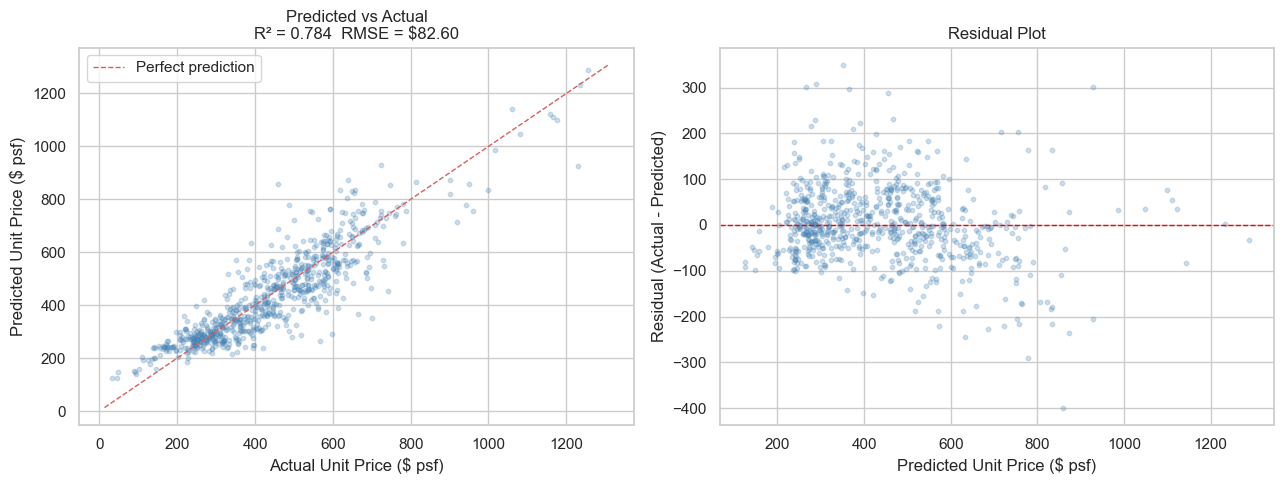

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.25, s=10, color="steelblue")
lims = [min(y_test_raw.min(), y_pred_raw.min()) - 20,
        max(y_test_raw.max(), y_pred_raw.max()) + 20]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual Unit Price ($ psf)")
axes[0].set_ylabel("Predicted Unit Price ($ psf)")
axes[0].set_title(f"Predicted vs Actual\nR² = {r2_raw:.3f}  RMSE = ${rmse_raw:.2f}")
axes[0].legend()

# Residuals
residuals = y_test_raw.values - y_pred_raw
axes[1].scatter(y_pred_raw, residuals, alpha=0.25, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Unit Price ($ psf)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## 7. Coefficient Interpretation

Coefficients are in **log-space** — the target is `Log_Unit_Price`.

**Interpretation**: A coefficient of `c` on a scaled feature means:
- A 1 standard deviation increase in that feature → `exp(c) - 1` × 100% change in unit price

**Note**: Coefficients are on scaled (z-score) features, so magnitude reflects relative importance — larger |coefficient| = stronger effect per standard deviation.

In [9]:
feature_names = NUMERICAL_COLS + BINARY_COLS
coefficients = best_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Pct_Change_per_SD": (np.exp(coefficients) - 1) * 100,
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"Intercept: {best_model.named_steps['model'].intercept_:.4f}")
print()
print("Feature Coefficients (sorted by |coefficient|):")
print(coef_df.to_string(index=False))

Intercept: 6.7553

Feature Coefficients (sorted by |coefficient|):
                    Feature  Coefficient  Pct_Change_per_SD
        Type of Sale_Resale    -0.528339         -41.041677
Floor Level_Non-First Floor    -0.200372         -18.157416
      Remaining_Lease_Years     0.199850          22.122016
                   Log_Area    -0.186649         -17.026531
        Region_North Region    -0.144543         -13.458236
   Region_North-East Region    -0.134412         -12.577016
         Region_East Region     0.105810          11.161046
      Planning_Area_Encoded     0.099240          10.433134
        Floor Level_Unknown     0.093182           9.766192
         Region_West Region    -0.086583          -8.294100
      Lease_Remaining_Ratio     0.067584           6.991980
         SORA_3M_Compounded    -0.043895          -4.294549
              dist_to_mrt_m     0.031005           3.149087
              CPI_All_Items     0.029342           2.977645
        GDP_YoY_Growth_Rate     0

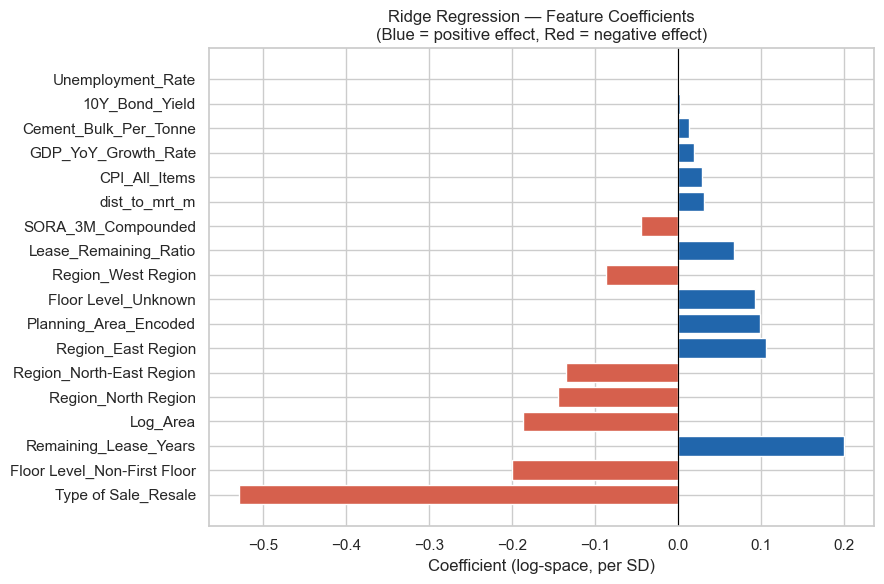

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2166ac" if c > 0 else "#d6604d" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-space, per SD)")
ax.set_title("Ridge Regression — Feature Coefficients\n(Blue = positive effect, Red = negative effect)")
plt.tight_layout()
plt.show()

## 8. Save Model

In [11]:
joblib.dump(best_model, "../models/ridge_pipeline.pkl")

print("Saved: models/ridge_pipeline.pkl")
print()
print("=" * 50)
print("RIDGE REGRESSION SUMMARY")
print("=" * 50)
print(f"Best alpha:          {best_alpha}")
print(f"CV RMSE (log):       {-grid_search.best_score_:.4f}")
print(f"Test RMSE:           ${rmse_raw:.2f} $/psf")
print(f"Test MAE:            ${mae_raw:.2f} $/psf")
print(f"Test R²:             {r2_raw:.4f}")
print(f"RMSE as % of mean:   {rmse_raw / y_test_raw.mean() * 100:.1f}%")

Saved: models/ridge_pipeline.pkl

RIDGE REGRESSION SUMMARY
Best alpha:          0.1
CV RMSE (log):       0.2211
Test RMSE:           $82.60 $/psf
Test MAE:            $61.04 $/psf
Test R²:             0.7845
RMSE as % of mean:   18.8%
